# Analysis and Visualization of Composite Diagnostics

**Author:** Mingshi Yang (mingshi3@illinois.edu)  
**Date:** 2026-06-21  

**Project:**  
*Characteristics of Midlatitude Cyclones under Climate Change in a Global Storm-Resolving Model*

**Description:**  
Created during Revision 1, this notebook generates precipitation-related Figures 5, 10, S14, S15, and S16 using composite-analysis-derived diagnostics.


In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
from numpy import dtype
from scipy import stats
from datetime import date
import collections
import cartopy.crs as ccrs
import os
from scipy.stats import circmean
import pickle
from scipy.ndimage import uniform_filter
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib import colors
from tqdm import tqdm

In [2]:
os.chdir('/data/keeling/a/mingshi3/c/xshield/Midlatitude-Cyclone-in-X-SHiELD/plotting')

In [3]:
track_dir = '../data/tracks'
composites_derived_dir = '../data/composites'
composites_raw_dir = '/data/keeling/a/mingshi3/c/xshield/composites'

In [4]:
experiments = [ 'PIRE',
                'PIRE_CO2_1270ppmv',
                'PIRE_PLUS_4K',
                'PIRE_PLUS_4K_CO2_1270ppmv']

experiments_display = [ 'CTRL   ',
                '+CO₂   ',
                '+4K    ',
                '+4K+CO₂']

expnames = ['ERA5   '] + experiments_display

colorlist = ['gray','black','C0','C1','C3']

In [5]:
tk = []
idx = []
for exp in experiments:
    tk.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Tracks.txt'))
    idx.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Indexes.txt'))

In [6]:
sels = []
for i in range(4):
    d = tk[i]
    sels.append(np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30)))

In [7]:
xplot = (np.arange(201)*25-2500) / 1000

In [8]:
# load precip
tk = []
idx = []
for exp in experiments:
    expf = exp.replace("\n","")
    tk.append(np.loadtxt(f'{track_dir}/TK2Y-{expf}/All_Tracks.txt'))
    idx.append(np.loadtxt(f'{track_dir}/TK2Y-{expf}/All_Indexes.txt'))

# circular mask, distance within r km is 1, outside is nan
def dmatrix(r,res):
    x = np.arange(-r,r+1e-10,res)
    y = x.copy()
    xx,yy = np.meshgrid(x,y)
    dm = np.ones_like(xx)
    dm[(xx**2+yy**2)>r**2] = np.nan
    return dm

dm250 = dmatrix(250,25)
dm500 = dmatrix(500,25)
dm1000 = dmatrix(1000,25)

presfc_XXX_file = f'{composites_derived_dir}/TK2Y-allexp_mean250_PRATEsfc.pkl'
if os.path.isfile(presfc_XXX_file):
    with open(presfc_XXX_file,'rb') as f:
        presfc_XXX = pickle.load(f)
else:
    presfc_XXX = []
    for i,exp in enumerate(experiments):
        d = tk[i]
        sel = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))
        print('l')
        expf = exp.replace("\n","")
        data = np.load(f'{composites_raw_dir}/TK2Y-{expf}_PRATEsfc.npy')
        print('m')
        presfc_XXX.append(np.nanmean(data[sel][:,90:111,90:111]*dm250[None,:],axis=(-1,-2))) # use distance mask to calculate area average
        del data
    with open(presfc_XXX_file,'wb') as f:
        pickle.dump(presfc_XXX,f)

evaposfc_XXX_file = f'{composites_derived_dir}/TK2Y-allexp_mean250_evaposfc.pkl'
if os.path.isfile(evaposfc_XXX_file):
    with open(evaposfc_XXX_file,'rb') as f:
        evaposfc_XXX = pickle.load(f)
else:
    evaposfc_XXX = []
    for i,exp in enumerate(experiments):
        d = tk[i]
        sel = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))
        print('l')
        expf = exp.replace("\n","")
        data = np.load(f'{composites_raw_dir}/TK2Y-{expf}_LHTFLsfc.npy')
        Lv=2.5e6
        print('m')
        evaposfc_XXX.append(np.nanmean(data[sel][:,90:111,90:111]*dm250[None,:],axis=(-1,-2))/Lv) # use distance mask to calculate area average
        del data
    with open(evaposfc_XXX_file,'wb') as f:
        pickle.dump(evaposfc_XXX,f)

In [9]:
cwv_XXX_file = f'{composites_derived_dir}/TK2Y-allexp_mean250_cwv_925-200.pkl'
if os.path.isfile(cwv_XXX_file):
    with open(cwv_XXX_file,'rb') as f:
        cwv_XXX = pickle.load(f)
else:
    cwv_XXX = []
    for i,exp in enumerate(experiments):
        d = tk[i]
        sel = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))
        print('l')
        expf = exp.replace("\n","")
        data = np.load(f'{composites_raw_dir}/TK2Y-{expf}_cwv_925-200.npy')
        print('m')
        cwv_XXX.append(np.nanmean(data[sel][:,90:111,90:111]*dm250[None,:],axis=(-1,-2)))
        del data
    with open(cwv_XXX_file,'wb') as f:
        pickle.dump(cwv_XXX,f)

In [10]:
cdqdt_XXX_file = f'{composites_derived_dir}/TK2Y-allexp_mean250_cdqdt_925-200.pkl'
if os.path.isfile(cdqdt_XXX_file):
    with open(cdqdt_XXX_file,'rb') as f:
        cdqdt_XXX = pickle.load(f)
else:
    cdqdt_XXX = []
    for i,exp in enumerate(experiments):
        d = tk[i]
        sel = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))
        print('l')
        expf = exp.replace("\n","")
        data = np.load(f'{composites_raw_dir}/TK2Y-{expf}_cdqdt_925-200.npy')
        print('m')
        cdqdt_XXX.append(np.nanmean(data[sel][:,90:111,90:111]*dm250[None,:],axis=(-1,-2)))
        del data
    with open(cdqdt_XXX_file,'wb') as f:
        pickle.dump(cdqdt_XXX,f)

Figure 5

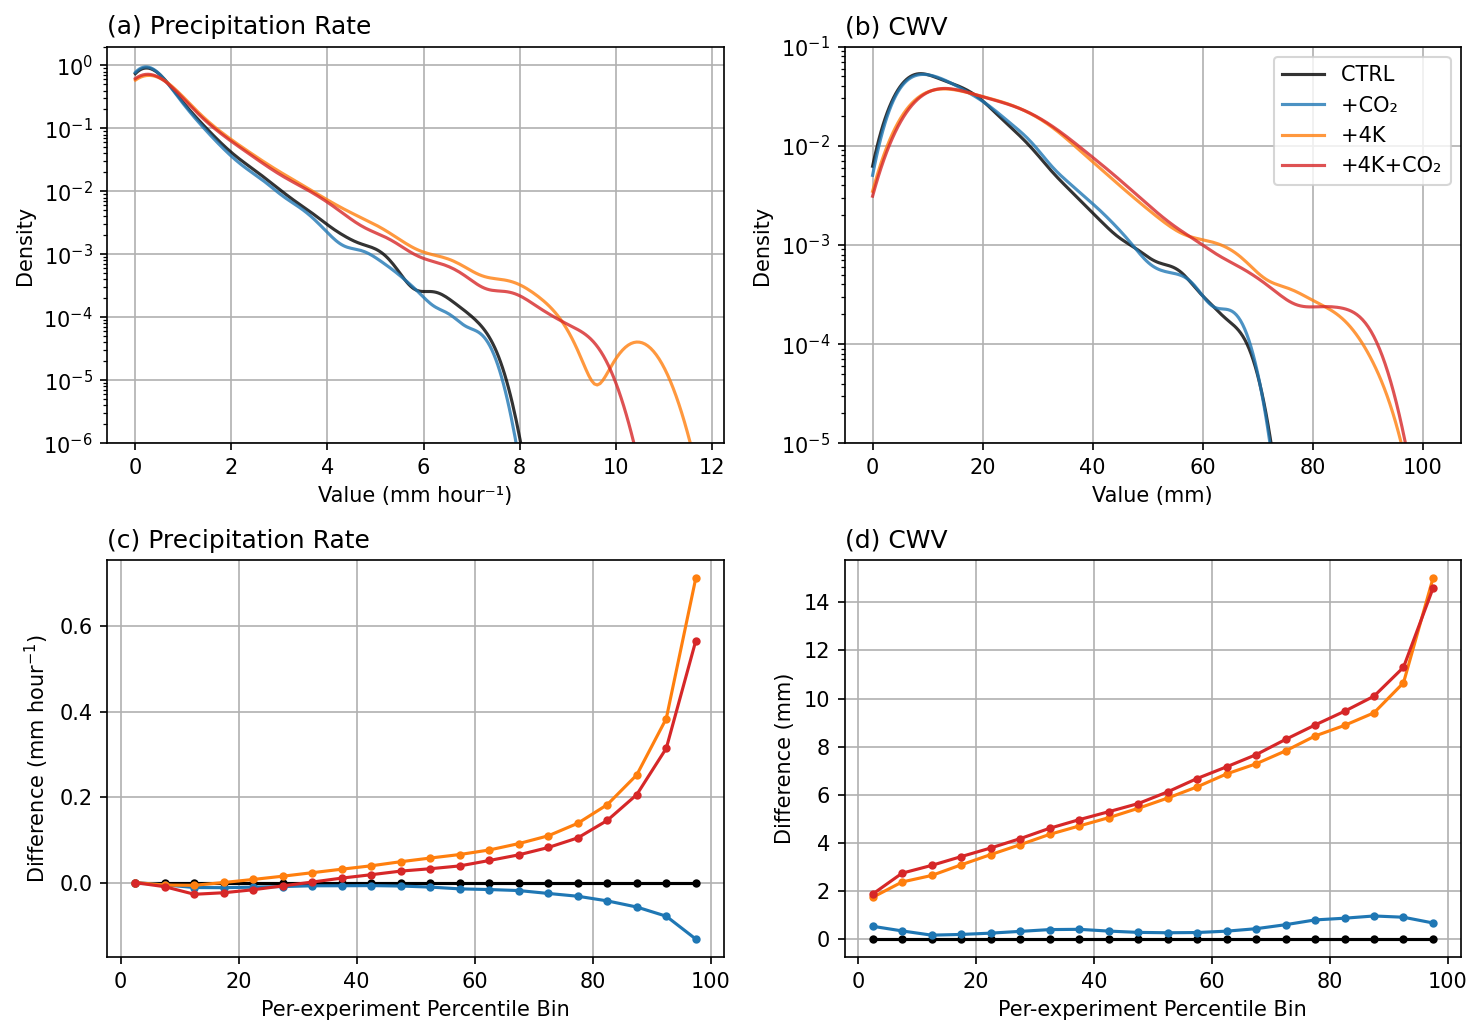

In [11]:
colorlist = ['gray','black','C0','C1','C3']

fig, axes = plt.subplots(2, 2, dpi=150, figsize=(10, 7))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# left column: original KDE plots
for i, pxxx in enumerate(presfc_XXX):
    sns.kdeplot(
        pxxx*3600,
        ax=axes[0,0],
        bw_adjust=4,
        clip=(0, np.inf),
        label=experiments_display[i],
        color=colorlist[i+1],
        alpha=0.8
    )

axes[0,0].set_yscale('log')
axes[0,0].set_ylim(1e-6, 2e0)
axes[0,0].set_title('(a) Precipitation Rate', loc='left')
axes[0,0].set_xlabel('Value (mm hour⁻¹)')
axes[0,0].grid()


for i, cxxx in enumerate(cwv_XXX):
    sns.kdeplot(
        cxxx,
        ax=axes[0,1],
        bw_adjust=2,
        clip=(0, np.inf),
        label=experiments_display[i].replace("\n",""),
        color=colorlist[i+1],
        alpha=0.8
    )

axes[0,1].set_ylim(1e-5, 1e-1)
axes[0,1].set_yscale('log')
axes[0,1].legend()
axes[0,1].set_title('(b) CWV', loc='left')
axes[0,1].set_xlabel('Value (mm)')
axes[0,1].grid()


# right column: original percentile-bin difference plots
xpct = np.arange(0, 100.1, 5)

datasets = [
    (presfc_XXX, 'Precipitation Rate', 'mm hour$^{-1}$'),
    (cwv_XXX, 'CWV', 'mm')
]

letters = ['c', 'd']

for icol, (dataset, title, unit) in enumerate(datasets):

    ax = axes[1,icol]

    mean_bins = []

    for i in range(4):
        vals = dataset[i]
        p_edges = np.nanpercentile(vals, xpct)

        mean_val = []
        for j in range(len(p_edges)-1):
            mask = (vals >= p_edges[j]) & (vals < p_edges[j+1])
            mean_val.append(np.nanmean(vals[mask]))

        mean_val = np.array(mean_val)

        # convert precipitation to mm/hr only
        if dataset is presfc_XXX:
            mean_val *= 3600

        mean_bins.append(mean_val)

    ref = mean_bins[0]

    for i in range(4):

        ax.plot(
            xpct[:-1] + 0.5*(xpct[1]-xpct[0]),
            mean_bins[i] - ref,
            label=f'{experiments_display[i]}',
            color=colorlist[i+1],
            marker='.'
        )

    #ax.axhline(0, color='gray', linewidth=1, linestyle='--')
    ax.set_ylabel(f'Difference ({unit})')
    ax.set_title(f'({letters[icol]}) {title}', loc='left')
    ax.set_xlabel('Per-experiment Percentile Bin')
    ax.grid()

axes[0,1].legend()

plt.tight_layout()

In [12]:
def area_mean_XXXkm(ds, radius_km=500.0):
    """
    Calculate 500-km radius area mean for all variables in dataset.

    Requires:
        ds coordinates:
            x (km, eastward positive)
            y (km, northward positive)

    Returns:
        xr.Dataset with same variables but spatially averaged.
    """

    xx, yy = np.meshgrid(ds['x'].values, ds['y'].values)

    mask = (xx**2 + yy**2) <= radius_km**2

    #print(f'Grid points within {radius_km:.0f} km:', mask.sum())

    data_vars = {}

    for var in ds.data_vars:

        arr = ds[var].values

        # detect spatial dimensions automatically
        if arr.ndim >= 2 and arr.shape[-2:] == mask.shape:

            # flatten spatial dims and average
            arr_mean = arr[..., mask].mean(axis=-1)

            # preserve remaining dimensions
            dims = ds[var].dims[:-2]

            data_vars[var] = (dims, arr_mean.astype(np.float32))

            #print(var, arr.shape, '->', arr_mean.shape)

        else:
            # keep untouched
            data_vars[var] = (ds[var].dims, arr)

    coords = {
        k: v for k, v in ds.coords.items()
        if k not in ['x', 'y']
    }

    ds_out = xr.Dataset(
        data_vars=data_vars,
        coords=coords,
        attrs=ds.attrs
    )

    ds_out.attrs['area_average_radius_km'] = radius_km

    return ds_out

In [13]:
# load qv budgets
ds_budgets = [xr.open_dataset(f'{composites_derived_dir}/TK2Y-{exp}_moisture-transport-budget-250_925-200vterm_mc.nc').compute() for exp in experiments[1:]]

In [14]:
ds_budgets_am = [area_mean_XXXkm(dsb,250) for dsb in ds_budgets]

Figures S14-S16

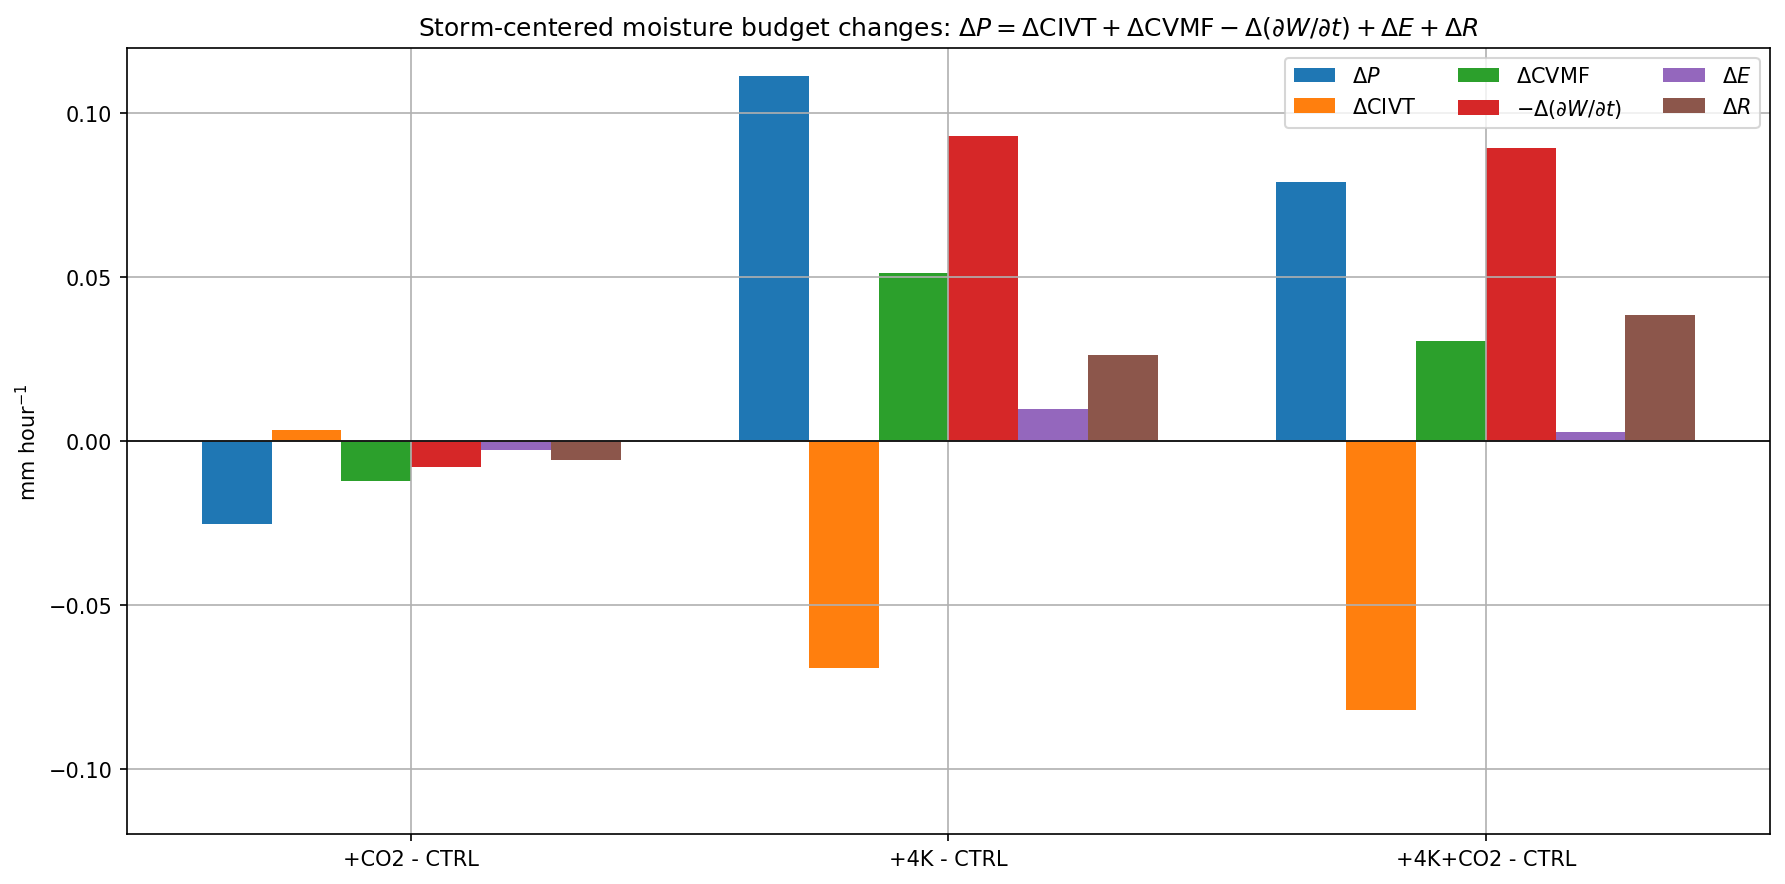

In [15]:
# Budget comparison using:
# ΔP = ΔCIVT + ΔCVMF - Δ(dW/dt) + ΔResidual

labels = ['+CO2 - CTRL', '+4K - CTRL', '+4K+CO2 - CTRL']
x = np.arange(len(labels))
width = 0.15

pairs = [
    (1, 0),  # +CO2 - CTRL
    (2, 0),  # +4K - CTRL
    (3, 0),  # +4K+CO2 - CTRL
]

width = 0.13

civt_all = []
vconv_all = []
dqdt_contrib_all = []
e_all = []
residual_all = []
p_all = []
rhs_sum_all = []

for target_i, ref_i in pairs:

    if ref_i == 0:
        mean_civt = np.mean(ds_budgets_am[target_i - 1]['CIVT_total'])
        mean_vconv = np.mean(ds_budgets_am[target_i - 1]['VCONV_total'])
    else:
        mean_civt = (
            np.mean(ds_budgets_am[target_i - 1]['CIVT_total'])
            - np.mean(ds_budgets_am[ref_i - 1]['CIVT_total'])
        )

        mean_vconv = (
            np.mean(ds_budgets_am[target_i - 1]['VCONV_total'])
            - np.mean(ds_budgets_am[ref_i - 1]['VCONV_total'])
        )

    mean_dqdt = (
        np.mean(cdqdt_XXX[target_i])
        - np.mean(cdqdt_XXX[ref_i])
    )

    mean_e = (
        np.mean(evaposfc_XXX[target_i])
        - np.mean(evaposfc_XXX[ref_i])
    )

    mean_p = (
        np.mean(presfc_XXX[target_i])
        - np.mean(presfc_XXX[ref_i])
    )

    mean_civt *= 3600
    mean_vconv *= 3600
    mean_dqdt *= 3600
    mean_e *= 3600
    mean_p *= 3600

    mean_rhs_sum = mean_civt + mean_vconv - mean_dqdt + mean_e
    mean_residual = mean_p - mean_rhs_sum

    civt_all.append(mean_civt)
    vconv_all.append(mean_vconv)
    dqdt_contrib_all.append(-mean_dqdt)
    e_all.append(mean_e)
    residual_all.append(mean_residual)
    p_all.append(mean_p)
    rhs_sum_all.append(mean_rhs_sum)

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

ax.bar(x - 2.5*width, p_all, width=width, label=r'$\Delta P$')
ax.bar(x - 1.5*width, civt_all, width=width, label=r'$\Delta$CIVT')
ax.bar(x - 0.5*width, vconv_all, width=width, label=r'$\Delta$CVMF')
ax.bar(x + 0.5*width, dqdt_contrib_all, width=width, label=r'$-\Delta(\partial W/\partial t)$')
ax.bar(x + 1.5*width, e_all, width=width, label=r'$\Delta E$')
ax.bar(x + 2.5*width, residual_all, width=width, label=r'$\Delta R$')

ax.axhline(0, color='k', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel(r'mm hour$^{-1}$')
ax.set_title(
    r'Storm-centered moisture budget changes: '
    r'$\Delta P = \Delta\mathrm{CIVT} + \Delta\mathrm{CVMF} '
    r'- \Delta(\partial W/\partial t) + \Delta E + \Delta R$'
)

ax.legend(ncol=3)
ax.set_ylim(-0.12,0.12)
ax.grid()
plt.tight_layout()
plt.show()

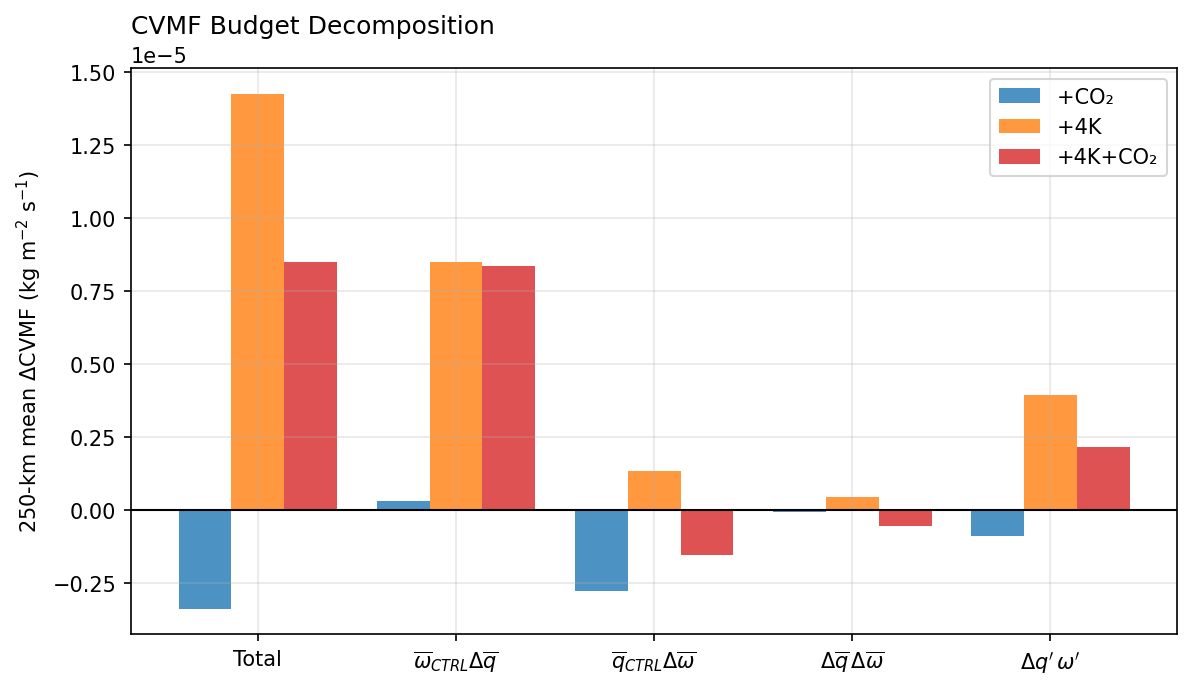

In [16]:
terms = [
    'VCONV_total',
    'VCONV_thermo_q',
    'VCONV_dynamic_omega',
    'VCONV_nonlinear',
    'VCONV_covariance',
]

term_labels = [
    r'Total',
    r'$\overline{\omega}_{CTRL}\Delta\overline{q}$',
    r'$\overline{q}_{CTRL}\Delta\overline{\omega}$',
    r'$\Delta\overline{q}\,\Delta\overline{\omega}$',
    r'$\Delta q^\prime\,\omega^\prime$',
]

nexp = len(ds_budgets_am)

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

x = np.arange(len(terms))

bar_width = 0.8 / nexp

for i, ds in enumerate(ds_budgets_am):

    vals = [
        float(ds[t].values)
        for t in terms
    ]

    ax.bar(
        x + i * bar_width - 0.4 + bar_width/2,
        vals,
        width=bar_width,
        label=expnames[i+2],   # assuming first budget is experiments[1]
        color=colorlist[i+2],
        alpha=0.8
    )

ax.axhline(0, color='black', linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(term_labels)

ax.set_ylabel('250-km mean CVMF change')
ax.set_title('CVMF Budget Decomposition', loc='left')
ax.set_ylabel(r'250-km mean $\Delta$CVMF (kg m$^{-2}$ s$^{-1}$)')

ax.legend()
ax.grid(alpha=0.3)

plt.show()

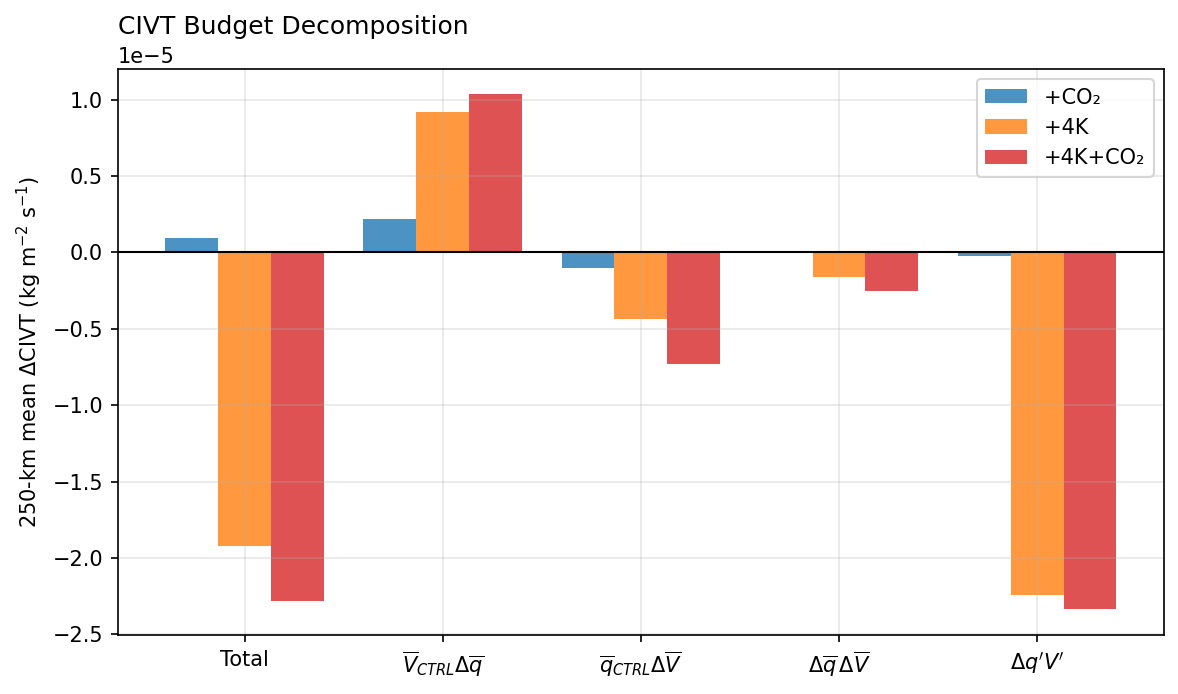

In [17]:
terms = [
    'CIVT_total',
    'CIVT_thermo',
    'CIVT_dynamic',
    'CIVT_nonlinear',
    'CIVT_covariance',
]

term_labels = [
    r'Total',
    r'$\overline{V}_{CTRL}\Delta\overline{q}$',
    r'$\overline{q}_{CTRL}\Delta\overline{V}$',
    r'$\Delta\overline{q}\,\Delta\overline{V}$',
    r'$\Delta q^\prime V^\prime$',
]

nexp = len(ds_budgets_am)

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

x = np.arange(len(terms))

bar_width = 0.8 / nexp

for i, ds in enumerate(ds_budgets_am):

    vals = [
        float(ds[t].values)
        for t in terms
    ]

    ax.bar(
        x + i * bar_width - 0.4 + bar_width/2,
        vals,
        width=bar_width,
        label=expnames[i+2],   # assuming first budget is experiments[1]
        color=colorlist[i+2],
        alpha=0.8
    )

ax.axhline(0, color='black', linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(term_labels)

ax.set_ylabel('250-km mean CIVT change')
ax.set_title('CIVT Budget Decomposition', loc='left')
ax.set_ylabel(r'250-km mean $\Delta$CIVT (kg m$^{-2}$ s$^{-1}$)')

ax.legend()
ax.grid(alpha=0.3)

plt.show()

Figure 10

In [18]:
# calculate area averaged omega first
var_name = 'omg'
levels = ['925', '850','500','200']
levels = np.array([int(i) for i in levels])

omgdist = []

for i, exp in enumerate(experiments):
    exp = exp.replace("\n","")
    MC_idx = (tk[i][:,1]<65)&(tk[i][:,1]>=30)&(tk[i][:,0]>2020000000)&(tk[i][:,0]<2022000000)

    omglvl = []
    for level in levels:
        print(level)
        omg_250_file = f'{composites_derived_dir}/TK2Y-{exp}_mean250_{var_name}{level}.npy'
        if os.path.isfile(omg_250_file):
            datam = np.load(omg_250_file)
        else:
            data = np.load(f'{composites_raw_dir}/TK2Y-{exp}_{var_name}{level}.npy')[MC_idx,90:111,90:111]
            data = data * dm250[None,:,:]
            datam = np.nanmean(data,axis=(-1,-2))
            np.save(omg_250_file,datam)
            del data
        omglvl.append(datam)
        
    omgdist.append(omglvl)


925
850
500
200
925
850
500
200
925
850
500
200
925
850
500
200


In [19]:
# load 250 km ivt
ivt = []
for i,exp in enumerate(experiments):
    d = tk[i]
    sel = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))
    ds = xr.open_dataset(f'/data/keeling/a/mingshi3/c/xshield/Midlatitude-Cyclone-in-X-SHiELD/data/composites/TK2Y-{exp}_ivt250_925-200vterm_mc.nc')
    ivt.append(ds['CIVT'].values+ds['VCONV_vertical_925_200'].values)

In [20]:
ds

<xarray.Dataset>
Dimensions:                 (sample: 24909)
Coordinates:
  * sample                  (sample) int64 0 1 2 3 4 ... 24905 24906 24907 24908
Data variables:
    IVTu                    (sample) float32 ...
    IVTv                    (sample) float32 ...
    CIVT                    (sample) float32 1.368e-05 -2.884e-05 ... -0.0002842
    CIVT_horizontal         (sample) float32 ...
    VCONV_vertical_925_200  (sample) float32 -5.413e-05 2.56e-05 ... -4.607e-05
    MFC_CIVT_plus_VCONV     (sample) float32 ...
Attributes:
    experiment:                               PIRE_PLUS_4K_CO2_1270ppmv
    description:                              Version 925vterm. 250-km radius...
    IVT_units:                                kg m-1 s-1
    CIVT_units:                               kg m-2 s-1
    VCONV_units:                              kg m-2 s-1
    MFC_units:                                kg m-2 s-1
    dx_m:                                     25000.0
    dy_m:                                     25000.0
    pressure_levels_hPa_for_horizontal_CIVT:  925,850,700,500,200
    boundary_levels_hPa_for_vertical_term:    925,200
    omega_to_pa_s:                            1.0
    area_average_radius_km:                   250

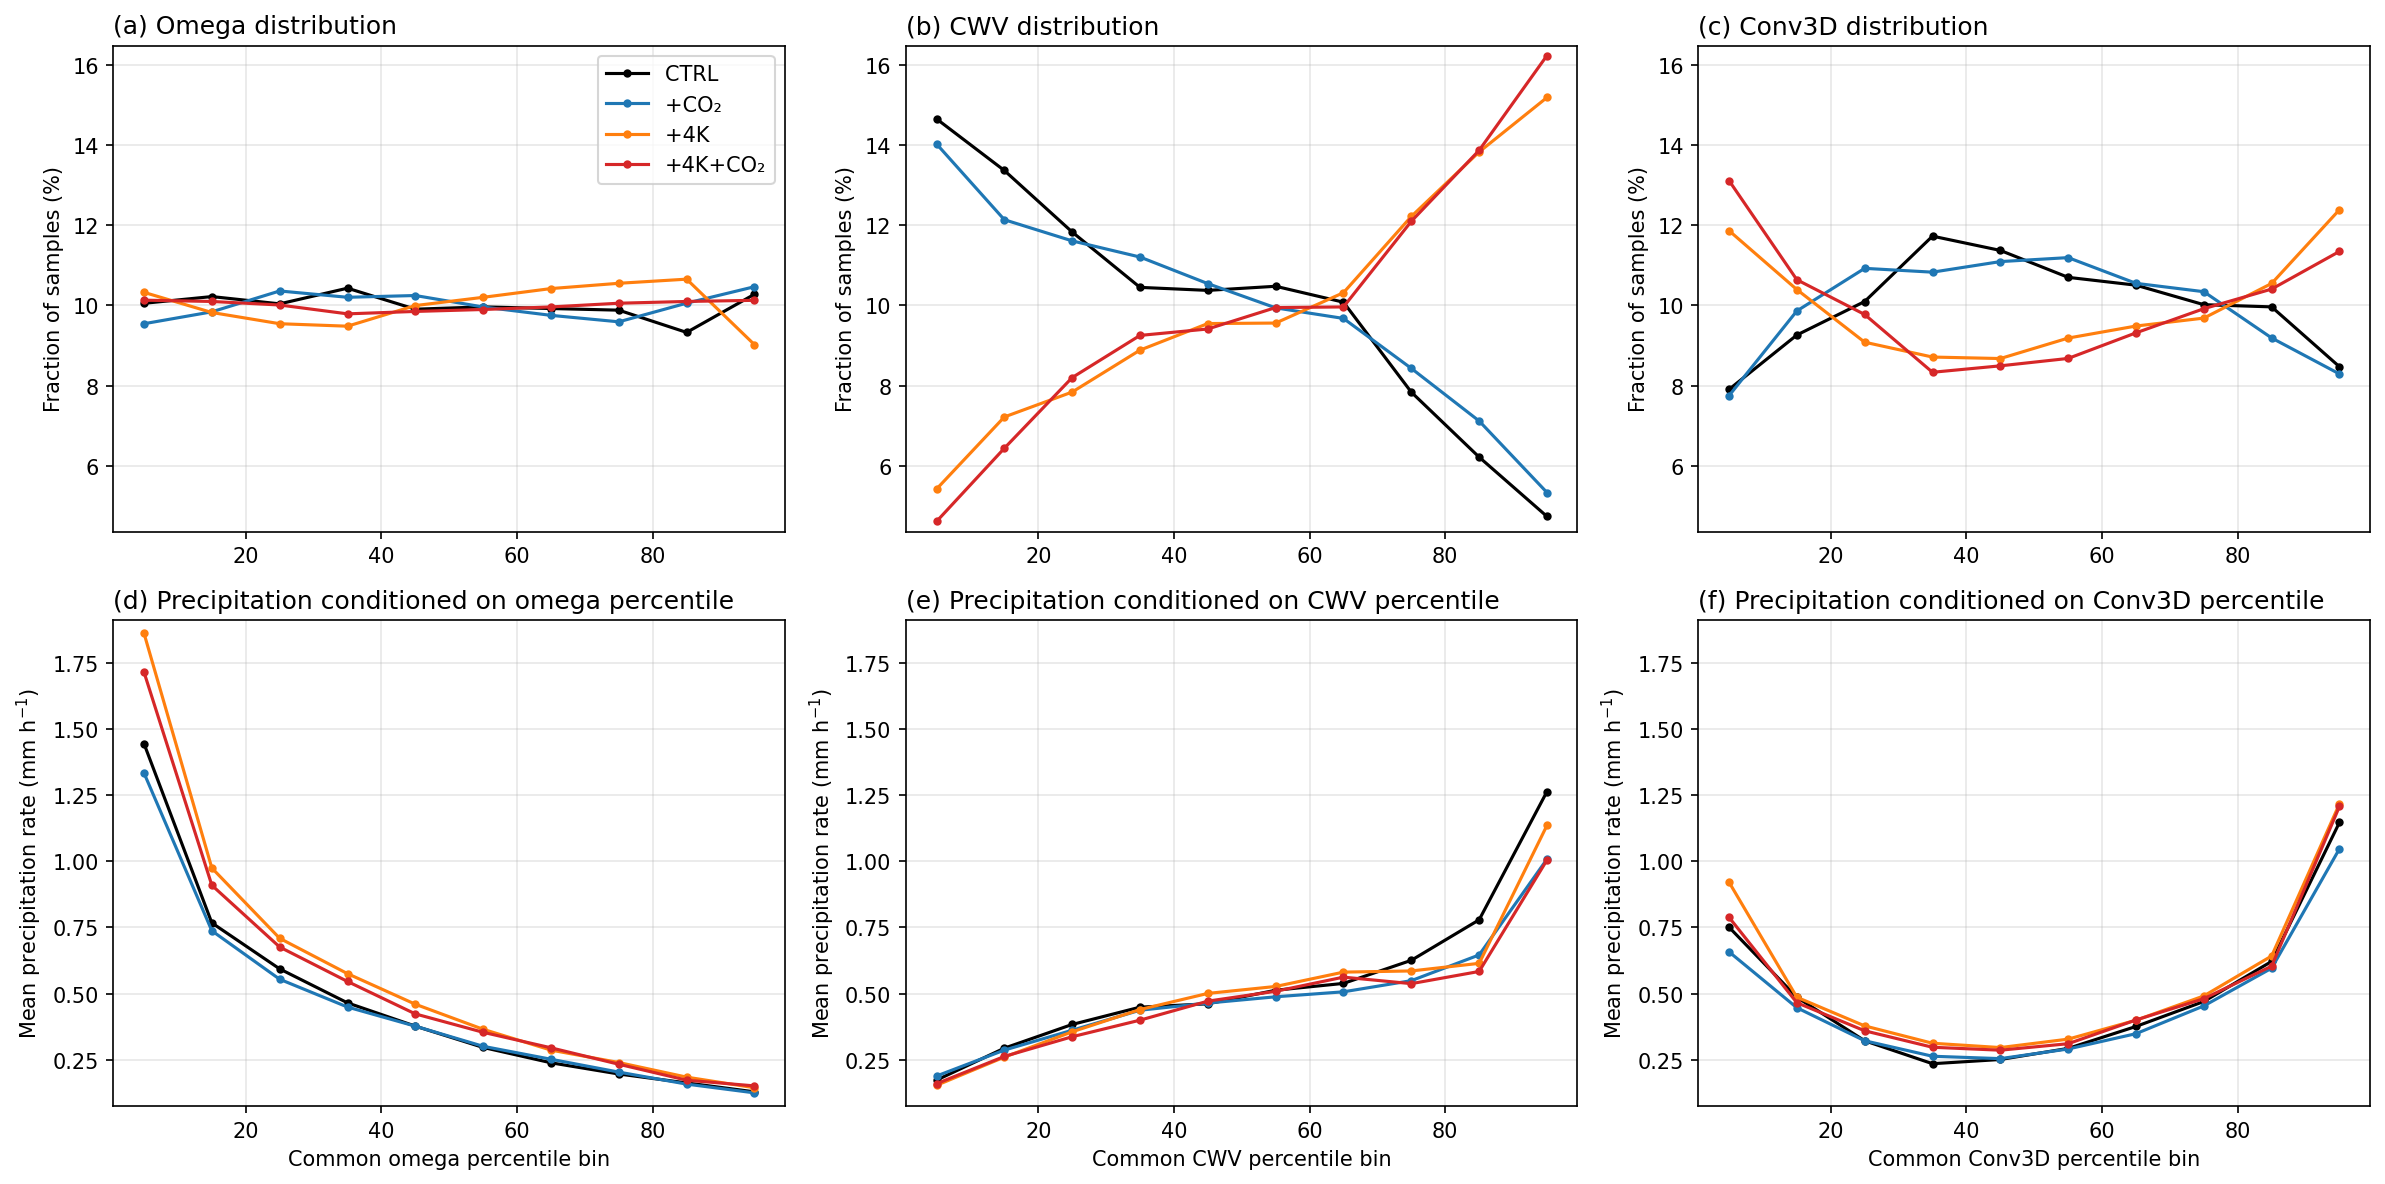

In [21]:
# omega, CWV, CIVT percentile-binned plot
xpct = np.arange(0, 100.1, 10)

fig, axes = plt.subplots(2, 3, dpi=150, figsize=(16, 8))

configs = [
    ([omgdist[j][1] * 3600 for j in range(len(experiments_display))],
     'Common omega percentile bin',
     '(a) Omega distribution',
     '(d) Precipitation conditioned on omega percentile'),

    ([cwv_XXX[j] for j in range(len(experiments_display))],
     'Common CWV percentile bin',
     '(b) CWV distribution',
     '(e) Precipitation conditioned on CWV percentile'),

    ([ivt[j] \
     for j in range(len(experiments_display))],
     'Common Conv3D percentile bin',
     '(c) Conv3D distribution',
     '(f) Precipitation conditioned on Conv3D percentile')
]

top_vals = []
bottom_vals = []

for icol, (xdata, xlabel, title_top, title_bottom) in enumerate(configs):

    x_all = np.concatenate([x[np.isfinite(x)] for x in xdata])
    x_edges = np.nanpercentile(x_all, xpct)
    x_mid = 0.5 * (xpct[:-1] + xpct[1:])

    for j, exp in enumerate(experiments_display):

        x = xdata[j]
        y = presfc_XXX[j] * 3600

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        frac = []
        y_mean = []

        for i in range(len(x_edges) - 1):

            if i == len(x_edges) - 2:
                m = (x >= x_edges[i]) & (x <= x_edges[i + 1])
            else:
                m = (x >= x_edges[i]) & (x < x_edges[i + 1])

            frac.append(np.sum(m) / len(x) * 100)

            if np.sum(m) > 0:
                y_mean.append(np.nanmean(y[m]))
            else:
                y_mean.append(np.nan)

        top_vals.extend(frac)
        bottom_vals.extend(y_mean)

        axes[0, icol].plot(
            x_mid, frac,
            marker='.',
            label=exp.replace('\n', ''),
            color=colorlist[j + 1]
        )

        axes[1, icol].plot(
            x_mid, y_mean,
            marker='.',
            color=colorlist[j + 1]
        )

    axes[0, icol].set_title(title_top, loc='left')
    axes[1, icol].set_title(title_bottom, loc='left')

    axes[0, icol].set_ylabel('Fraction of samples (%)')
    axes[1, icol].set_ylabel('Mean precipitation rate (mm h$^{-1}$)')

    axes[1, icol].set_xlabel(xlabel)

# unify y axes
top_ylim = [np.nanmin(top_vals)-0.25, np.nanmax(top_vals)+0.25]
bottom_ylim = [np.nanmin(bottom_vals)-0.05, np.nanmax(bottom_vals)+0.05]

for ax in axes[0]:
    ax.set_ylim(top_ylim)
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_ylim(bottom_ylim)
    ax.grid(alpha=0.3)

axes[0, 0].legend()

plt.tight_layout()
plt.show()